# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Egi Julian
- **Email:** egyjulian8@gmail.com
- **ID Dicoding:** egijulian

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh perbedaan musim (season) terhadap jumlah total penyewaan sepeda harian?
- Apakah terdapat korelasi antara suhu udara (temp) dengan jumlah pengguna sepeda (baik casual maupun registered)?

## Import Semua Packages/Library yang Digunakan



In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [9]:
day_df = pd.read_csv("Data/day.csv", delimiter=",")
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Di data day ini terdapat 16 kolom
- saya membuat data frame baru dengan nama day_df

### Assessing Data

In [10]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- di info data ini tidak ada yang missing value
- Ketidaksesuaian data type pada dteday, harusnya datetime
- tidak ada juga yang duplicate

### Cleaning Data

In [11]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

**Insight:**
- Mengganti tipe data pada dteday menjadi datetime

## Exploratory Data Analysis (EDA)

### Explore ...

In [12]:
# Melihat statistik deskriptif dasar untuk data numerik
day_df.describe()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


**Insight:**
- diseason terdapat 4 data yaitu 1-4
- weathersit terdapat 3 data yaitu 1-4

In [13]:
# Melihat korelasi antar variabel dengan cnt
day_df.corr(numeric_only=True) ['cnt'].sort_values(ascending=False)

cnt           1.000000
registered    0.945517
casual        0.672804
atemp         0.631066
instant       0.628830
temp          0.627494
yr            0.566710
season        0.406100
mnth          0.279977
weekday       0.067443
workingday    0.061156
holiday      -0.068348
hum          -0.100659
windspeed    -0.234545
weathersit   -0.297391
Name: cnt, dtype: float64

**Insight:**
- ada beberapa kolom data yang berkolerasi dengan cnt, seperti registered, casual dll

In [14]:
# eksplorasi berdasarkan season
day_df.groupby('season')['cnt'].mean().reset_index()

,season,cnt
0,1,2604.132597
1,2,4992.331522
2,3,5644.303191
3,4,4728.162921


**Insight:**
- di dalam season terdapat 4 karakteristik data, dimana angka 1 menunjukkan 'springer', angka 2 menunjukkan 'summer, angka 3 menunjukkan 'fall' , angka 4 menunjukkan 'winter
- rata rata terbanyak terdapat pada musim fall

In [15]:
# eksplorasi berdasarkan weathersit
day_df.groupby('weathersit')['cnt'].mean().reset_index()

,weathersit,cnt
0,1,4876.786177
1,2,4035.862348
2,3,1803.285714


**Insight:**
- di dalam weathersit terdapat 4 karakteristik data, dimana angka 1 menunjukkan 'clear', angka 2 menunjukkan 'mist', angka 3 menunjukkan 'light snow' , angka 4 menunjukkan 'heavy rain'
- rata rata terbanyak terdapat pada weathersit clear
- tidak terdapat data yang menunjukan 4 / heavy rain

In [16]:
# eksplorasi perbandingan workingday dengan casual & registerred
day_df.groupby('workingday')[['casual', 'registered']].mean().reset_index()

,workingday,casual,registered
0,0,1371.134199,2959.034632
1,1,606.570000,3978.250000


**Insight:**
- data ini memiliki 2 karakteristika yaitu 0 untuk hari libur dan 1 untuk hari kerja
- jumlah sepeda tersewa terbanyak yaitu pada saat hari kerja, yang menandakan digunakan untuk berangkat kerja

## Visualization & Explanatory Analysis

### Pertanyaan 1: Prediksi jumlah sepeda sewaan per hari berdasarkan kondisi lingkungan dan musim.

C:\Users\Acer\AppData\Local\Temp\ipykernel_20100\1121387105.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=day_df, palette='viridis')


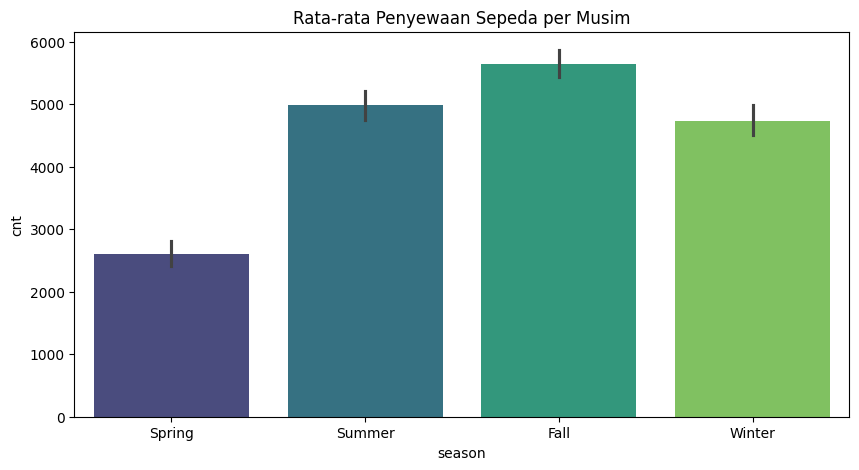

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(x='season', y='cnt', data=day_df, palette='viridis')
plt.title('Rata-rata Penyewaan Sepeda per Musim')
plt.xticks([0, 1, 2, 3], ['Spring', 'Summer', 'Fall', 'Winter'])
plt.show()

### Pertanyaan 2: Prediksi jumlah sepeda sewaan per hari berdasarkan kondisi weekday dan workingday.

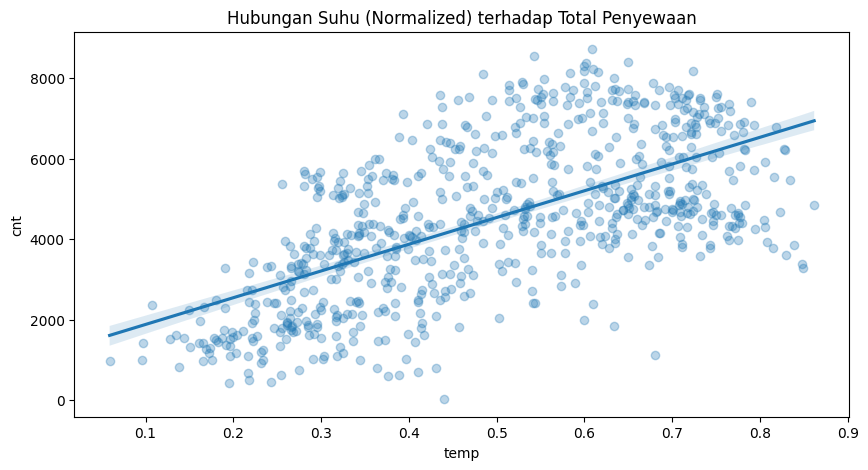

In [18]:
plt.figure(figsize=(10, 5))
sns.regplot(x='temp', y='cnt', data=day_df, scatter_kws={'alpha':0.3})
plt.title('Hubungan Suhu (Normalized) terhadap Total Penyewaan')
plt.xlabel('temp')
plt.ylabel('cnt')
plt.show()

**Insight:**
- season fall merupakan penyewaan terbanyak dengan +5000 penyewa sepeda, disusul dengan winter dan season paling sedikit penyewa sepeda adalah saat spring yaitu dibawah 3000
- terdapat korelasi yang sangat signifikan antara temp dan cnt, semakin tinggi temp maka semakin tinggi juga penyewa sepeda
- titik-titik data yang paling banyak terkumpuk antara temp 0.4 sampai 0.7

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 : pada musim fall dan summer perusahaan bisa memaksimalkan stok sepeda karena saat musim ini penyewa akan banyak, dan saat musim spring perusahaan bisa fokus pada maintenance karena penyewa sepeda menurun
- Conclution pertanyaan 2 : perusahaan dapat memantau suhu sebagai faktor prediktor yang sangat kuat, dengan memantau peramalan cuaca pihak perusahaan bisa mempersiapkan kapan maintenance dan kapan harus stok sepeda semaksimal mungkin

